In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# Define your Kaggle credentials
KAGGLE_USERNAME = ""  # Replace with your username
KAGGLE_TOKEN = ""      # Replace with your API key

# Create .kaggle directory if it doesn't exist
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Create kaggle.json from variables
kaggle_credentials = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_TOKEN
}

kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')

# Write credentials to kaggle.json
with open(kaggle_json_path, 'w') as f:
    json.dump(kaggle_credentials, f)

# Set proper permissions (Unix/Linux/Mac)
os.chmod(kaggle_json_path, 0o600)

logging.info("Kaggle credentials configured successfully.")


INFO:root:Kaggle credentials configured successfully.


In [ ]:
!kaggle datasets download -d enider/yawdd-dataset
!unzip -q yawdd-dataset.zip -d yawdd

Dataset URL: https://www.kaggle.com/datasets/enider/yawdd-dataset
License(s): MIT
Resuming from 1243611136 bytes (4216136178 bytes left)...
100% 5.08G/5.08G [00:49<00:00, 85.1MB/s]



In [ ]:
!pip install opencv-python dlib torch scikit-learn pandas seaborn requests nbformat

In [ ]:
# =========================
# CELL 1 — CONFIG + SEEDS
# =========================

import logging
import random
import numpy as np
import torch
import warnings
from dataclasses import dataclass
from pathlib import Path

warnings.filterwarnings("ignore")

# Logging setup
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


@dataclass
class Config:
    """Pipeline configuration."""
    FPS: int = 20
    WINDOW_SIZE: int = 16
    BATCH_SIZE: int = 8
    PATIENCE: int = 8
    SEED: int = 42
    DATASET_PATHS: list = None
    OUTPUT_DIR: str = "outputs"

    def __post_init__(self):
        if self.DATASET_PATHS is None:
            self.DATASET_PATHS = [
                r'/content/yawdd/Mirror/Mirror/Female_mirror',
                r'/content/yawdd/Mirror/Mirror/Male_mirror Avi Videos',
            ]

        # Validate dataset paths
        for path in self.DATASET_PATHS:
            p = Path(path)
            if not p.exists():
                logger.error(f"❌ Dataset path NOT found: {path}")
            else:
                logger.info(f"✅ Valid dataset path: {path}")

        # Ensure output directory exists
        Path(self.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
        logger.info(f"Output directory set to: {Path(self.OUTPUT_DIR).resolve()}")


def set_global_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    logger.info(f"Global seed set to {seed}")


# Initialize
config = Config()
set_global_seeds(config.SEED)
logger.info("Configuration initialized successfully.")

In [4]:
logging.getLogger().setLevel(logging.INFO)

In [5]:
!cp "/content/drive/MyDrive/CO-RES/temporal_features.csv" "/content/outputs/temporal_features.csv"

In [ ]:
# ==========================================
# CELL 2 — FINAL VERSION
# ==========================================

import re
import pandas as pd
from pathlib import Path


def parse_yawdd_directory(dataset_paths, output_dir):

    # Strict pattern for FemaleNoGlasses / MaleNoGlasses
    pattern = re.compile(
        r'(\d+)-(FemaleNoGlasses|MaleNoGlasses)(?:-([a-zA-Z]+))?\.avi$',
        re.IGNORECASE
    )

    data_records = []
    subject_session_counter = {}

    for dataset_path in dataset_paths:
        path_obj = Path(dataset_path)

        if not path_obj.exists():
            logger.error(f"Invalid dataset path: {dataset_path}")
            continue

        logger.info(f"Scanning: {path_obj.resolve()}")

        for file_path in path_obj.rglob("*.avi"):
            file = file_path.name
            match = pattern.search(file)

            if not match:
                continue

            subject_id = match.group(1)
            metadata_str = match.group(2)
            raw_label = match.group(3) if match.group(3) else "Unknown"

            # Session counting per subject
            subject_session_counter[subject_id] = (
                subject_session_counter.get(subject_id, 0) + 1
            )

            session_id = subject_session_counter[subject_id]

            data_records.append({
                "file_path": str(file_path.resolve()),
                "filename": file,
                "subject_id": subject_id,
                "session_id": session_id,
                "metadata_str": metadata_str,
                "raw_label": raw_label
            })

    df = pd.DataFrame(data_records)

    if df.empty:
        logger.error("❌ No matching FemaleNoGlasses or MaleNoGlasses videos found.")
        return df

    # Save full inventory
    full_csv_path = Path(output_dir) / "all_noglasses_metadata.csv"
    df.to_csv(full_csv_path, index=False)
    logger.info(f"Saved full metadata → {full_csv_path.resolve()}")

    # Keep subjects with >= 3 sessions
    session_counts = df.groupby("subject_id")["session_id"].max()
    valid_subjects = session_counts[session_counts >= 3].index

    df_filtered = df[df["subject_id"].isin(valid_subjects)].copy()

    filtered_csv_path = Path(output_dir) / "filtered_noglasses_3plus_sessions.csv"
    df_filtered.to_csv(filtered_csv_path, index=False)

    logger.info(f"Saved filtered metadata → {filtered_csv_path.resolve()}")

    # ===== PRINT STATS =====
    print("\n===== DATASET SUMMARY =====")
    print("Total videos (NoGlasses only):", len(df))
    print("Unique subjects (before filtering):", df['subject_id'].nunique())
    print("Videos after >=3 session filter:", len(df_filtered))
    print("Unique subjects after filtering:", df_filtered['subject_id'].nunique())

    return df_filtered


# Run Cell 2
df_raw = parse_yawdd_directory(
    config.DATASET_PATHS,
    config.OUTPUT_DIR
)

In [ ]:
import pandas as pd
import logging
from pathlib import Path

logger = logging.getLogger(__name__)

def map_binary_from_filtered_csv() -> pd.DataFrame:
    """
    Load filtered_noglasses_3plus_sessions.csv from output directory.
    Convert:
        Normal → Alert
        Talking → Alert
        Yawning → Drowsy
        TalkingYawning → Drowsy
    Display class counts and save new CSV.
    """

    input_path = Path(config.OUTPUT_DIR) / "filtered_noglasses_3plus_sessions.csv"

    if not input_path.exists():
        logger.error(f"Filtered CSV not found at: {input_path.resolve()}")
        return pd.DataFrame()

    df = pd.read_csv(input_path)
    logger.info(f"Loaded filtered dataset → {input_path.resolve()}")

    if df.empty:
        logger.error("Filtered CSV is empty.")
        return df

    # ─────────────────────────────────────────
    # Binary Mapping Logic
    # ─────────────────────────────────────────
    def determine_class(label: str) -> str:
        label = str(label).lower()

        if "talkingyawning" in label:
            return "Drowsy"
        elif "yawning" in label:
            return "Drowsy"
        elif "talking" in label:
            return "Alert"
        elif "normal" in label:
            return "Alert"
        else:
            return "Unknown"

    df["target_class"] = df["raw_label"].apply(determine_class)

    # Keep only valid samples
    df_valid = df[df["target_class"] != "Unknown"].copy()

    # ─────────────────────────────────────────
    # Display Video Counts
    # ─────────────────────────────────────────
    class_counts = df_valid["target_class"].value_counts()

    print("\n===== CLASS DISTRIBUTION =====")
    for cls, count in class_counts.items():
        print(f"{cls}: {count} videos")

    print(f"Total videos: {len(df_valid)}")

    # ─────────────────────────────────────────
    # Save New CSV
    # ─────────────────────────────────────────
    output_path = Path(config.OUTPUT_DIR) / "binary_alert_drowsy_3plus_sessions.csv"

    try:
        df_valid.to_csv(output_path, index=False)
        logger.info(f"Saved binary mapped dataset → {output_path.resolve()}")
    except Exception as e:
        logger.error(f"Failed to save CSV: {e}")

    return df_valid


# Run Cell 3
if __name__ == "__main__":
    df_mapped = map_binary_from_filtered_csv()


===== CLASS DISTRIBUTION =====
Alert: 112 videos
Drowsy: 63 videos
Total videos: 175


In [ ]:
import os
import bz2
import requests
import dlib
import numpy as np
from pathlib import Path
from typing import Tuple

logger = logging.getLogger(__name__)

# ---------------------------------------------------
# 1️⃣ AUTO DOWNLOAD & EXTRACT DLIB 68 LANDMARK MODEL
# ---------------------------------------------------

def setup_dlib_predictor() -> dlib.shape_predictor:
    """
    Downloads and extracts shape_predictor_68_face_landmarks.dat
    if not available locally. Returns initialized predictor.
    """

    model_dir = Path(config.OUTPUT_DIR)
    model_path = model_dir / "shape_predictor_68_face_landmarks.dat"
    compressed_path = model_dir / "shape_predictor_68_face_landmarks.dat.bz2"

    if not model_path.exists():

        logger.info("Dlib 68 landmark model not found. Downloading...")

        url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"

        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(compressed_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        logger.info("Download complete. Extracting...")

        with bz2.BZ2File(compressed_path) as fr, open(model_path, "wb") as fw:
            fw.write(fr.read())

        compressed_path.unlink()  # remove bz2 file
        logger.info("Extraction complete.")

    else:
        logger.info("Dlib landmark model already exists.")

    predictor = dlib.shape_predictor(str(model_path))
    logger.info("Dlib 68-point predictor initialized.")

    return predictor


# ---------------------------------------------------
# 2️⃣ MATHEMATICAL FEATURE FUNCTIONS (STRICT TYPES)
# ---------------------------------------------------

def compute_ear(eye: np.ndarray) -> float:
    """
    Eye Aspect Ratio (EAR)
    eye shape: (6,2)
    """
    A: float = np.linalg.norm(eye[1] - eye[5])
    B: float = np.linalg.norm(eye[2] - eye[4])
    C: float = np.linalg.norm(eye[0] - eye[3])

    ear: float = (A + B) / (2.0 * C)
    return float(ear)


def compute_mar(mouth: np.ndarray) -> float:
    """
    Mouth Aspect Ratio (MAR)
    mouth shape: (8,2)
    """
    A: float = np.linalg.norm(mouth[2] - mouth[6])
    B: float = np.linalg.norm(mouth[3] - mouth[5])
    C: float = np.linalg.norm(mouth[0] - mouth[4])

    mar: float = (A + B) / (2.0 * C)
    return float(mar)


def compute_head_tilt(left_eye: np.ndarray, right_eye: np.ndarray) -> float:
    """
    Computes head tilt angle in degrees.
    Uses eye centers.
    """
    left_center: np.ndarray = left_eye.mean(axis=0)
    right_center: np.ndarray = right_eye.mean(axis=0)

    dx: float = float(right_center[0] - left_center[0])
    dy: float = float(right_center[1] - left_center[1])

    angle: float = np.degrees(np.arctan2(dy, dx))
    return float(angle)


def compute_perclos(ear_values: np.ndarray, threshold: float = 0.25) -> float:
    """
    PERCLOS = percentage of frames where EAR < threshold.
    """
    if len(ear_values) == 0:
        return 0.0

    closed_frames: int = int(np.sum(ear_values < threshold))
    perclos: float = closed_frames / len(ear_values)

    return float(perclos)


# ---------------------------------------------------
# 3️⃣ EXECUTION CALLER
# ---------------------------------------------------

if __name__ == "__main__":

    logger.info("Initializing Dlib and facial metric functions...")

    predictor_68 = setup_dlib_predictor()

    logger.info("Cell 4 setup complete.")

In [ ]:
import cv2
import numpy as np
import pandas as pd
import time
from pathlib import Path
from typing import List, Tuple
from tqdm import tqdm

logger = logging.getLogger(__name__)


# -------------------------------------------------------
# Convert Dlib shape to NumPy
# -------------------------------------------------------

def shape_to_np(shape: dlib.full_object_detection) -> np.ndarray:
    coords = np.zeros((68, 2), dtype=np.float32)
    for i in range(68):
        coords[i] = (shape.part(i).x, shape.part(i).y)
    return coords


# -------------------------------------------------------
# Process Single Video (Grayscale Safe Version)
# -------------------------------------------------------

def process_video(
    video_path: str,
    detector: dlib.fhog_object_detector,
    predictor: dlib.shape_predictor,
    fps_target: int
) -> List[Tuple[float, float, float, float]]:

    cap = cv2.VideoCapture(video_path, cv2.CAP_FFMPEG)

    if not cap.isOpened():
        logger.warning(f"Failed to open video: {video_path}")
        return []

    native_fps = cap.get(cv2.CAP_PROP_FPS)
    if native_fps == 0 or np.isnan(native_fps):
        native_fps = fps_target

    frame_skip = max(int(native_fps // fps_target), 1)

    frame_count = 0
    features = []
    ear_buffer = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame is None:
            frame_count += 1
            continue

        if frame_count % frame_skip != 0:
            frame_count += 1
            continue

        try:
            # Convert to grayscale
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Ensure uint8
            if gray.dtype != np.uint8:
                gray = gray.astype(np.uint8)

            # Ensure contiguous memory
            gray = np.ascontiguousarray(gray)

            # Validate grayscale shape (H, W)
            if gray.ndim != 2:
                frame_count += 1
                continue

            # Face detection
            faces = detector(gray, 0)

            if len(faces) > 0:
                shape = predictor(gray, faces[0])
                landmarks = shape_to_np(shape)

                left_eye = landmarks[42:48]
                right_eye = landmarks[36:42]
                mouth = landmarks[60:68]

                ear_left = compute_ear(left_eye)
                ear_right = compute_ear(right_eye)
                ear = (ear_left + ear_right) / 2.0

                mar = compute_mar(mouth)
                tilt = compute_head_tilt(left_eye, right_eye)

                ear_buffer.append(ear)
                perclos = compute_perclos(np.array(ear_buffer))

                features.append((ear, mar, tilt, perclos))

        except Exception as e:
            logger.warning(f"Frame error in {video_path}: {e}")

        frame_count += 1

    cap.release()
    return features


# -------------------------------------------------------
# Sliding Window Generator
# -------------------------------------------------------

def generate_windows(
    features: List[Tuple[float, float, float, float]],
    window_size: int
) -> np.ndarray:

    sequences = []

    for i in range(len(features) - window_size + 1):
        window = np.array(features[i:i + window_size], dtype=np.float32)
        sequences.append(window)

    if len(sequences) == 0:
        return np.empty((0, window_size, 4), dtype=np.float32)

    return np.stack(sequences)


# -------------------------------------------------------
# Main Extraction Pipeline
# -------------------------------------------------------

def extract_temporal_features() -> None:

    input_csv = Path(config.OUTPUT_DIR) / "binary_alert_drowsy_3plus_sessions.csv"

    if not input_csv.exists():
        logger.error(f"CSV not found: {input_csv.resolve()}")
        return

    df = pd.read_csv(input_csv)
    logger.info(f"Loaded metadata → {input_csv.resolve()}")

    detector = dlib.get_frontal_face_detector()
    predictor = setup_dlib_predictor()

    all_sequences = []
    metadata_rows = []

    logger.info("Processing videos...")

    start_time = time.time()

    with tqdm(total=len(df),
              desc="Videos",
              unit="video",
              dynamic_ncols=True) as pbar:

        for _, row in df.iterrows():

            video_start = time.time()

            video_path = row["file_path"]
            subject_id = str(row["subject_id"])
            session_id = int(row["session_id"])
            label = row["target_class"]

            features = process_video(
                video_path,
                detector,
                predictor,
                config.FPS
            )

            windows = generate_windows(
                features,
                config.WINDOW_SIZE
            )

            for seq in windows:
                all_sequences.append(seq)
                metadata_rows.append({
                    "subject_id": subject_id,
                    "session_id": session_id,
                    "target_class": label
                })

            elapsed_video = time.time() - video_start
            pbar.set_postfix({"last_video_sec": f"{elapsed_video:.2f}s"})
            pbar.update(1)

    total_time = time.time() - start_time
    logger.info(f"Total extraction time: {total_time:.2f} sec")

    if len(all_sequences) == 0:
        logger.warning("No temporal sequences generated.")
        return

    temporal_array = np.stack(all_sequences)

    logger.info(f"Final temporal tensor shape: {temporal_array.shape}")

    # Flatten (samples, 16, 4) → (samples, 64)
    flattened = temporal_array.reshape(temporal_array.shape[0], -1)

    df_features = pd.DataFrame(flattened)
    meta_df = pd.DataFrame(metadata_rows)

    final_df = pd.concat(
        [meta_df.reset_index(drop=True),
         df_features.reset_index(drop=True)],
        axis=1
    )

    output_path = Path(config.OUTPUT_DIR) / "temporal_features.csv"
    final_df.to_csv(output_path, index=False)

    logger.info(f"Saved temporal features → {output_path.resolve()}")


# -------------------------------------------------------
# Execution Caller
# -------------------------------------------------------

if __name__ == "__main__":
    logger.info("Starting Temporal Feature Extraction...")
    extract_temporal_features()
    logger.info("Cell 5 completed successfully.")

Videos: 100%|██████████| 175/175 [1:21:16<00:00, 27.87s/video, last_video_sec=27.69s]


In [6]:
# ==========================================================
# CELL 4 — VBFLLFA MODEL (CSP + TRANSFORMER)
# ==========================================================
import torch
import torch.nn as nn
import logging

logger = logging.getLogger(__name__)

class CSPLayer(nn.Module):
    """
    Learnable CSP-style projection layer.
    Projects 4 raw features into a higher-dimensional space (csp_dim).
    """
    def __init__(self, input_dim: int, csp_dim: int) -> None:
        super().__init__()
        self.projection = nn.Linear(input_dim, csp_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (batch, 16, 4) -> (batch, 16, csp_dim)
        return self.projection(x)

class VBFLLFA(nn.Module):
    """
    Video-Based Fatigue Learning with Feature-Level Fusion Attention
    """
    def __init__(
        self,
        input_dim: int = 4,
        csp_dim: int = 32,
        num_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.1,
        num_classes: int = 1  # FIXED: Set to 1 for Binary BCE Loss
    ) -> None:
        super().__init__()

        # 1. CSP Feature Projection
        self.csp = CSPLayer(input_dim, csp_dim)

        # 2. Transformer Encoder (Temporal Attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=csp_dim,
            nhead=num_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 3. Classification Head
        self.classifier = nn.Sequential(
            nn.LayerNorm(csp_dim),
            nn.Linear(csp_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes) # Outputs a single Logit
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input x: (batch_size, 16, 4)
        Returns: (batch_size, 1)
        """
        # Step 1: Project 4 features to CSP space
        x = self.csp(x)

        # Step 2: Apply Transformer Attention over the 16 frames
        x = self.transformer(x)

        # Step 3: Global Temporal Pooling (Average the 16 frames)
        x = torch.mean(x, dim=1)

        # Step 4: Final Classification
        logits = self.classifier(x)
        return logits

print("VBFLLFA Model (1-node output) defined successfully.")

VBFLLFA Model (1-node output) defined successfully.


In [7]:
# ==========================================================
# CELL 8 — DYNAMIC SUBJECT-WISE FOLD PREPARATION
# ==========================================================

import torch
import pandas as pd
import numpy as np
import logging
from pathlib import Path
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

logger = logging.getLogger(__name__)

# ----------------------------------------------------------
# 1️⃣ Custom Dataset Class (Fixes NameError in Cell 9)
# ----------------------------------------------------------
class TemporalDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

# ----------------------------------------------------------
# 2️⃣ Global Data Loading & Summary
# ----------------------------------------------------------
input_path = Path(config.OUTPUT_DIR) / "temporal_features.csv"
df = pd.read_csv(input_path)

# Extract metadata for splitting
subject_ids = df["subject_id"].values
labels_raw = df["target_class"].values

# Encode labels (Alert=0, Drowsy=1)
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_raw)

# Reshape features to (Samples, 16, 4)
X = df.iloc[:, 3:].values.reshape(-1, config.WINDOW_SIZE, 4)

# ----------------------------------------------------------
# 3️⃣ Dynamic Fold Mapping & Reporting
# ----------------------------------------------------------
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=config.SEED)

print("="*50)
print("DYNAMIC DATASET SUMMARY")
print("="*50)
print(f"Total Subjects : {len(np.unique(subject_ids))}")
print(f"Total Videos   : {len(df.groupby(['subject_id', 'session_id']))}")
print(f"Total Windows  : {len(X)}")
print("-"*50)

# Display which subjects belong to which fold
for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, labels_encoded, groups=subject_ids)):
    fold_subjects = np.unique(subject_ids[val_idx])
    fold_video_count = len(df.iloc[val_idx].groupby(['subject_id', 'session_id']))

    print(f"FOLD {fold_idx + 1}:")
    print(f"  - Test Subjects ({len(fold_subjects)}) : {fold_subjects.tolist()}")
    print(f"  - Test Videos   : {fold_video_count}")
    print(f"  - Test Windows  : {len(val_idx)}")
    print("-"*30)

print("="*50)
print("Cell 8 Complete: Variables 'X', 'labels_encoded', and 'sgkf' are ready for Cell 9.")

INFO:numexpr.utils:NumExpr defaulting to 2 threads.


DYNAMIC DATASET SUMMARY
Total Subjects : 40
Total Videos   : 171
Total Windows  : 92501
--------------------------------------------------
FOLD 1:
  - Test Subjects (8) : [9, 20, 31, 34, 38, 43, 45, 47]
  - Test Videos   : 35
  - Test Windows  : 18968
------------------------------
FOLD 2:
  - Test Subjects (6) : [15, 17, 26, 28, 30, 33]
  - Test Videos   : 22
  - Test Windows  : 11589
------------------------------
FOLD 3:
  - Test Subjects (11) : [4, 6, 10, 14, 18, 19, 27, 35, 39, 41, 42]
  - Test Videos   : 50
  - Test Windows  : 29461
------------------------------
FOLD 4:
  - Test Subjects (7) : [11, 12, 22, 23, 29, 36, 37]
  - Test Videos   : 36
  - Test Windows  : 18655
------------------------------
FOLD 5:
  - Test Subjects (8) : [1, 2, 5, 13, 21, 24, 40, 44]
  - Test Videos   : 28
  - Test Windows  : 13828
------------------------------
Cell 8 Complete: Variables 'X', 'labels_encoded', and 'sgkf' are ready for Cell 9.


INFO:__main__:Initiating training on: cuda
INFO:__main__:Class Balance -> Alert: 65915, Drowsy: 26586
INFO:__main__:Using pos_weight: 2.4793 to prioritize Drowsy detection.
INFO:__main__:
STARTING FOLD 1 / 5
INFO:__main__:Fold 1 | Ep 01 | Train Loss: 0.8730 - Acc: 0.6401 | Val Loss: 1.0211 - Acc: 0.4815
INFO:__main__:Fold 1 | Ep 02 | Train Loss: 0.8215 - Acc: 0.6650 | Val Loss: 1.0936 - Acc: 0.5643
INFO:__main__:Fold 1 | Ep 03 | Train Loss: 0.7859 - Acc: 0.6952 | Val Loss: 1.0678 - Acc: 0.5119
INFO:__main__:Fold 1 | Ep 04 | Train Loss: 0.7541 - Acc: 0.7201 | Val Loss: 1.1225 - Acc: 0.5302
INFO:__main__:Fold 1 | Ep 05 | Train Loss: 0.7261 - Acc: 0.7355 | Val Loss: 1.1012 - Acc: 0.5780
INFO:__main__:Fold 1 | Ep 06 | Train Loss: 0.6696 - Acc: 0.7625 | Val Loss: 1.2606 - Acc: 0.5346
INFO:__main__:Fold 1 | Ep 07 | Train Loss: 0.6473 - Acc: 0.7694 | Val Loss: 1.2393 - Acc: 0.5331
INFO:__main__:Fold 1 | Ep 08 | Train Loss: 0.6331 - Acc: 0.7747 | Val Loss: 1.3751 - Acc: 0.5255
INFO:__main__:Fo

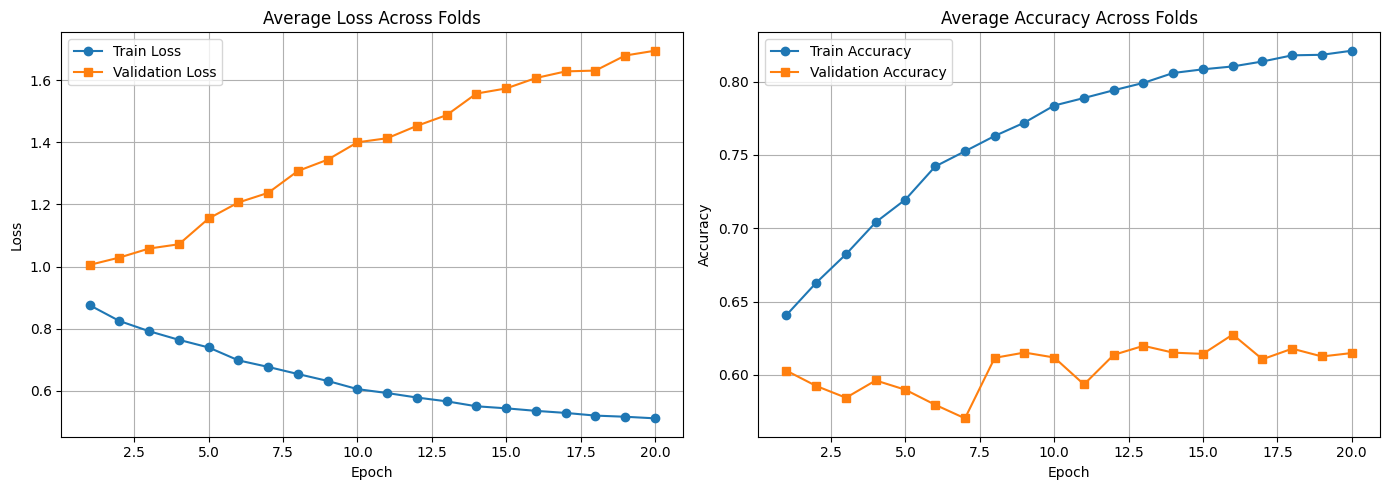

In [8]:
# ==========================================================
# CELL 9 — 5-FOLD SUBJECT-WISE TRAINING PHASE (WITH GRAPHS)
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import logging
import copy
import numpy as np
from pathlib import Path

logger = logging.getLogger(__name__)

def train_kfold():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.info(f"Initiating training on: {device}")

    # 1. RESTORED: Calculate pos_weight dynamically to handle class imbalance
    num_alert = (labels_encoded == 0).sum()
    num_drowsy = (labels_encoded == 1).sum()
    weight_ratio = num_alert / num_drowsy
    pos_weight = torch.tensor([weight_ratio], dtype=torch.float32).to(device)

    logger.info(f"Class Balance -> Alert: {num_alert}, Drowsy: {num_drowsy}")
    logger.info(f"Using pos_weight: {weight_ratio:.4f} to prioritize Drowsy detection.")

    # Dictionaries to store fold metrics for plotting
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    # 2. Iterate through the 5 Folds defined in Cell 8
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, labels_encoded, groups=subject_ids)):
        logger.info(f"\n{'='*40}\nSTARTING FOLD {fold_idx + 1} / 5\n{'='*40}")

        # 3. Scale Features within the fold
        scaler = StandardScaler()
        X_train_flat = X[train_idx].reshape(-1, 4)
        X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, config.WINDOW_SIZE, 4)

        X_val_flat = X[val_idx].reshape(-1, 4)
        X_val_scaled = scaler.transform(X_val_flat).reshape(-1, config.WINDOW_SIZE, 4)

        # 4. Initialize DataLoaders
        train_loader = DataLoader(
            TemporalDataset(X_train_scaled, labels_encoded[train_idx]),
            batch_size=config.BATCH_SIZE, shuffle=True
        )
        val_loader = DataLoader(
            TemporalDataset(X_val_scaled, labels_encoded[val_idx]),
            batch_size=config.BATCH_SIZE, shuffle=False
        )

        # 5. Model Setup
        model = VBFLLFA(num_classes=1).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = optim.Adam(model.parameters(), lr=5e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

        best_val_loss = float('inf')
        patience_counter = 0
        best_model_wts = copy.deepcopy(model.state_dict())

        fold_train_losses, fold_val_losses = [], []
        fold_train_accs, fold_val_accs = [], []

        # 6. Training Epochs
        for epoch in range(20):
            # --- TRAIN ---
            model.train()
            train_loss, train_correct, train_total = 0.0, 0, 0
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device).unsqueeze(1)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * inputs.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                train_correct += (preds == targets).sum().item()
                train_total += targets.size(0)

            epoch_train_loss = train_loss / train_total
            epoch_train_acc = train_correct / train_total

            # --- VALIDATION ---
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device).unsqueeze(1)
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)

                    val_loss += loss.item() * inputs.size(0)
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                    val_correct += (preds == targets).sum().item()
                    val_total += targets.size(0)

            epoch_val_loss = val_loss / val_total
            epoch_val_acc = val_correct / val_total
            scheduler.step(epoch_val_loss)

            # Record metrics
            fold_train_losses.append(epoch_train_loss)
            fold_val_losses.append(epoch_val_loss)
            fold_train_accs.append(epoch_train_acc)
            fold_val_accs.append(epoch_val_acc)

            logger.info(f"Fold {fold_idx+1} | Ep {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

            # Early Stopping Check
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                # patience_counter = 0
            # else:
                # patience_counter += 1

            # if patience_counter >= config.PATIENCE:
            #     logger.info(f"Early stopping triggered for Fold {fold_idx+1}")
            #     break

        # Save fold metrics to global history
        history['train_loss'].append(fold_train_losses)
        history['val_loss'].append(fold_val_losses)
        history['train_acc'].append(fold_train_accs)
        history['val_acc'].append(fold_val_accs)

        # Save the best model weights for this specific fold
        save_path = Path(config.OUTPUT_DIR) / f"best_fold_{fold_idx + 1}.pth"
        torch.save(best_model_wts, save_path)
        logger.info(f"Fold {fold_idx+1} weights saved to drive.")

    # 7. Plotting the Overall Training Progress (Average across folds)
    # We pad the lists with their last value to make them the same length for averaging
    max_epochs = max(len(f) for f in history['train_loss'])

    avg_train_loss = np.mean([f + [f[-1]]*(max_epochs-len(f)) for f in history['train_loss']], axis=0)
    avg_val_loss = np.mean([f + [f[-1]]*(max_epochs-len(f)) for f in history['val_loss']], axis=0)
    avg_train_acc = np.mean([f + [f[-1]]*(max_epochs-len(f)) for f in history['train_acc']], axis=0)
    avg_val_acc = np.mean([f + [f[-1]]*(max_epochs-len(f)) for f in history['val_acc']], axis=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Plot
    ax1.plot(range(1, max_epochs+1), avg_train_loss, label='Train Loss', marker='o')
    ax1.plot(range(1, max_epochs+1), avg_val_loss, label='Validation Loss', marker='s')
    ax1.set_title('Average Loss Across Folds')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend()

    # Accuracy Plot
    ax2.plot(range(1, max_epochs+1), avg_train_acc, label='Train Accuracy', marker='o')
    ax2.plot(range(1, max_epochs+1), avg_val_acc, label='Validation Accuracy', marker='s')
    ax2.set_title('Average Accuracy Across Folds')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_kfold()

INFO:__main__:Processing OOF Predictions for Fold 1...
INFO:__main__:Processing OOF Predictions for Fold 2...
INFO:__main__:Processing OOF Predictions for Fold 3...
INFO:__main__:Processing OOF Predictions for Fold 4...
INFO:__main__:Processing OOF Predictions for Fold 5...



      FINAL VIDEO-LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Alert     0.7442    0.5926    0.6598       108
      Drowsy     0.4824    0.6508    0.5541        63

    accuracy                         0.6140       171
   macro avg     0.6133    0.6217    0.6069       171
weighted avg     0.6477    0.6140    0.6208       171

Overall Video-Level Accuracy: 61.40%


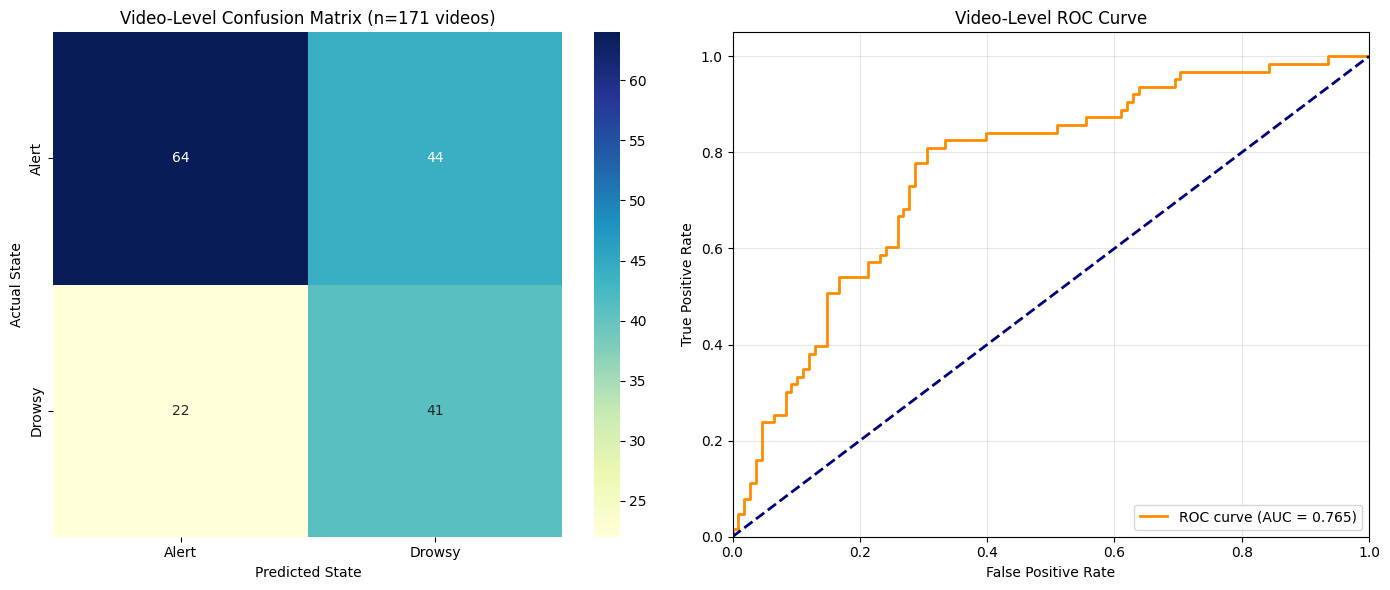

Report saved to: outputs/final_video_performance.csv


In [9]:
# ==========================================================
# CELL 10 — FINAL VIDEO-LEVEL EVALUATION (MAJORITY VOTE & ROC)
# ==========================================================
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from pathlib import Path
import logging

logger = logging.getLogger(__name__)

def evaluate_video_performance():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_window_preds = np.zeros(len(X))
    all_window_probs = np.zeros(len(X)) # Track raw probabilities for ROC

    # 1. Generate Predictions & Probabilities for each Fold
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, labels_encoded, groups=subject_ids)):
        logger.info(f"Processing OOF Predictions for Fold {fold_idx + 1}...")

        scaler = StandardScaler()
        scaler.fit(X[train_idx].reshape(-1, 4))
        X_val_scaled = scaler.transform(X[val_idx].reshape(-1, 4)).reshape(-1, config.WINDOW_SIZE, 4)

        model = VBFLLFA(num_classes=1).to(device)
        model_path = Path(config.OUTPUT_DIR) / f"best_fold_{fold_idx + 1}.pth"
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
        model.eval()

        val_loader = DataLoader(TemporalDataset(X_val_scaled, labels_encoded[val_idx]), batch_size=config.BATCH_SIZE)

        fold_preds = []
        fold_probs = []
        with torch.no_grad():
            for inputs, _ in val_loader:
                outputs = model(inputs.to(device))
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).int()

                fold_preds.extend(preds.cpu().numpy().flatten())
                fold_probs.extend(probs.cpu().numpy().flatten())

        all_window_preds[val_idx] = fold_preds
        all_window_probs[val_idx] = fold_probs

    # 2. Create Results DataFrame
    results_df = pd.DataFrame({
        "subject_id": df["subject_id"],
        "session_id": df["session_id"],
        "true_label": df["target_class"],
        "true_encoded": le.transform(df["target_class"]),
        "window_pred": le.inverse_transform(all_window_preds.astype(int)),
        "window_prob": all_window_probs
    })

    # 3. Aggregate to Video Level
    video_results = results_df.groupby(['subject_id', 'session_id']).agg({
        'true_label': 'first',
        'true_encoded': 'first',
        'window_pred': lambda x: x.mode()[0], # Majority Vote for Classification
        'window_prob': 'mean' # Mean Probability for ROC Curve
    }).reset_index()

    y_true_str = video_results['true_label']
    y_pred_str = video_results['window_pred']
    y_true_enc = video_results['true_encoded']
    y_prob = video_results['window_prob']

    # 4. Final Metrics and Visualization
    print("\n" + "="*45)
    print("      FINAL VIDEO-LEVEL CLASSIFICATION REPORT")
    print("="*45)
    print(classification_report(y_true_str, y_pred_str, digits=4))

    vid_acc = accuracy_score(y_true_str, y_pred_str)
    print(f"Overall Video-Level Accuracy: {vid_acc * 100:.2f}%")

    # ----- Plotting Figures -----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # A) Confusion Matrix
    cm = confusion_matrix(y_true_str, y_pred_str, labels=["Alert", "Drowsy"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
                xticklabels=["Alert", "Drowsy"], yticklabels=["Alert", "Drowsy"], ax=ax1)
    ax1.set_title(f"Video-Level Confusion Matrix (n={len(video_results)} videos)")
    ax1.set_xlabel("Predicted State")
    ax1.set_ylabel("Actual State")

    # B) ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true_enc, y_prob)
    roc_auc = auc(fpr, tpr)

    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Video-Level ROC Curve')
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save results
    video_results.to_csv(Path(config.OUTPUT_DIR) / "final_video_performance.csv", index=False)
    print(f"Report saved to: {Path(config.OUTPUT_DIR) / 'final_video_performance.csv'}")

if __name__ == "__main__":
    evaluate_video_performance()